# Import Library yang Diperlukan

In [12]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load Dataset

In [13]:
df = pd.read_csv('heart.csv')

In [14]:
# Melihat 5 Data Teratas
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [15]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


# Data Cleaning

In [16]:
# Cek Data Duplikat
df.duplicated().sum()

np.int64(0)

In [17]:
# Cek Missing Value
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Dapat dilihat dari Hasil Cek Duplikat dan Cek Missing Value, dihasilkan bahwasannya dataset tidak memiliki nilai yang duplikat dan nilai yang hilang

In [18]:
numerical_cols = df.select_dtypes(['int64', 'float64']).columns.to_list()

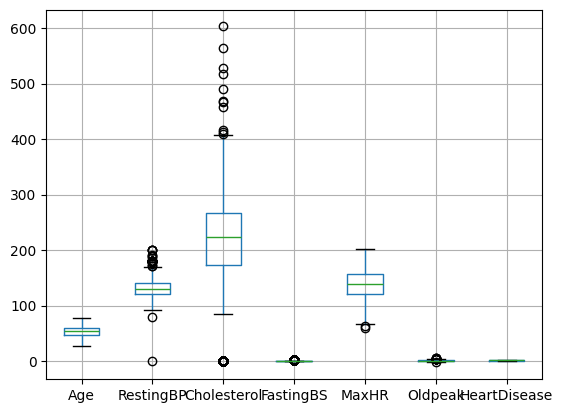

In [19]:
# Cek Outlier

df[numerical_cols].boxplot()
plt.show()

In [20]:
# Handle Outlier
def handleOutlier(column) :
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

In [21]:
for column in df[numerical_cols] :
    handleOutlier(column)

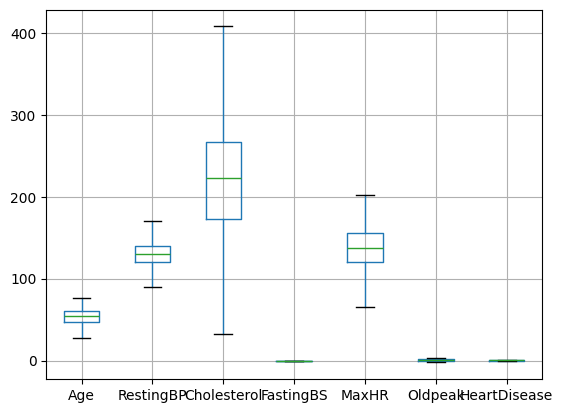

In [22]:
df[numerical_cols].boxplot()
plt.show()

Dapat dilihat dari hasil visualisasi boxplot sebelumnya dataset memiliki banyak nilai pencilan atau outlier, setelah dilakukan handle outlier dengan metode IQR outlier tersebut diganti dengan nilai batas atas dan batas bawah tiap-tiap kolom

# Eksplorasi Data

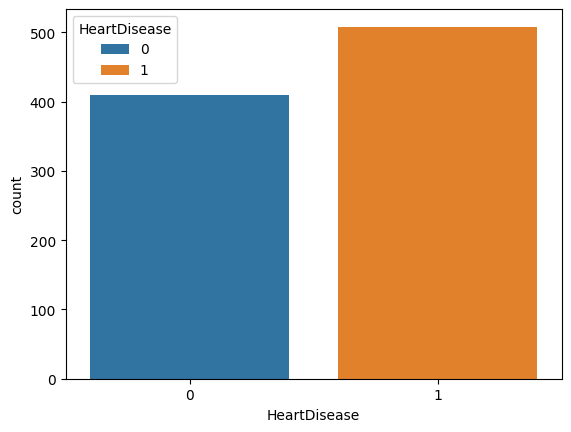

In [27]:
sns.countplot(data=df, x='HeartDisease', hue='HeartDisease')
plt.show()